In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [3]:
dataset_train = pd.read_csv(r'C:\Users\Jaum\Desktop\CursoIA\10.Detecção de Anomalias\Salestrain.csv')

In [4]:
dataset_train.shape

(96, 1)

In [5]:
dataset_train

,data
0,112
1,118
2,132
3,129
4,121
...,...
91,405
92,355
93,306
94,271


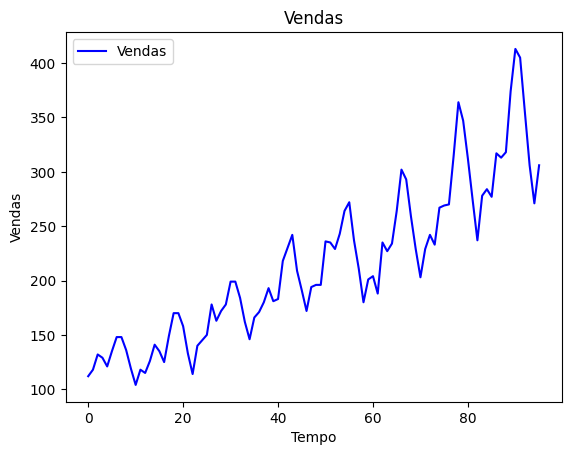

In [6]:
plt.plot(dataset_train, color='b', label='Vendas')
plt.title('Vendas')
plt.xlabel('Tempo')
plt.ylabel("Vendas")
plt.legend()
plt.show()

In [7]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(dataset_train)

In [8]:
X_train = []
y_train = []
for i in range(90, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-90:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train = np.array(X_train).reshape(-1, 90, 1)
y_train = np.array(y_train)

In [9]:
modelo = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=100),
    Dropout(0.2),
    Dense(units=1)
])

In [12]:
modelo.compile(optimizer='adam', loss='mean_squared_error')
modelo.fit(X_train, y_train, epochs=300, batch_size=1)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - loss: 0.3538
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.0420
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 0.1638
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - loss: 0.0715
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.1016
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - loss: 0.0593
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - loss: 0.0151
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.0864
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0525
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - loss: 0.0291
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0606
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0342
Epoch 13/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 0.0382
Epoch 14/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0374
Epoch 15/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0426
Epo

In [13]:
dataset_test = pd.read_csv(r'C:\Users\Jaum\Desktop\CursoIA\10.Detecção de Anomalias\Salestest.csv')
dataset_test.shape

(48, 1)

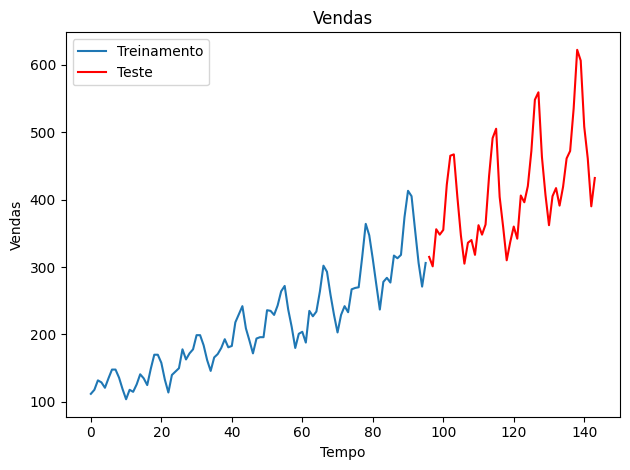

In [26]:
train_values = dataset_train['data'].values
test_values = dataset_test['data'].values

total = pd.Series(np.concat((train_values, test_values), axis=0))

plt.figure()
total[:len(train_values)].plot(label='Treinamento')
total[len(train_values):].plot(label='Teste', color='r')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.title('Vendas')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
dataset_test_anomalias = dataset_test.copy()
dataset_test_anomalias['data'] = dataset_test_anomalias['data'].astype(float)
dataset_test_anomalias.iloc[:10, dataset_test_anomalias.columns.get_loc('data')] = 100
dataset_test_anomalias.iloc[10:35, dataset_test_anomalias.columns.get_loc('data')] = np.random.uniform(100, 600, size=25)
dataset_test_anomalias.iloc[35:, dataset_test_anomalias.columns.get_loc('data')] = 100

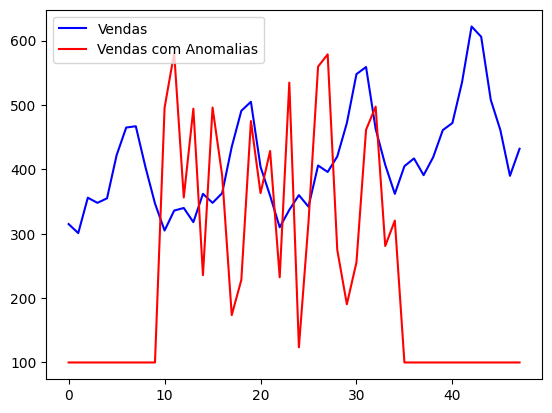

In [37]:
plt.plot(dataset_test, color='b', label='Vendas')
plt.plot(dataset_test_anomalias, color='r', label='Vendas com Anomalias')
plt.legend()
plt.show()

In [43]:
inputs = total[len(total) - len(dataset_test) - 90:]
inputs = pd.DataFrame(inputs, columns=['data'])
inputs = sc.fit_transform(inputs)

In [50]:
total_anomalies = pd.Series(np.concat((train_values, dataset_test_anomalias['data'].values), axis=0))
inputs_anomalies = total_anomalies[len(total_anomalies) - len(dataset_test) - 90:]
inputs_anomalies = pd.DataFrame(inputs_anomalies, columns=['data'])
inputs_anomalies = sc.fit_transform(inputs_anomalies)

In [51]:
X_test = []
X_test_anomalies = []
for i in range(90, len(inputs)):
    X_test.append(inputs[i-90:i, 0])
    X_test_anomalies.append(inputs_anomalies[i-90:i, 0])
X_test, X_test_anomalies = np.array(X_test), np.array(X_test_anomalies)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test_anomalies = np.reshape(X_test_anomalies, (X_test_anomalies.shape[0], X_test_anomalies.shape[1], 1))

In [52]:
predicted_values = modelo.predict(X_test)
predicted_values = sc.inverse_transform(predicted_values)

predicted_values_anomalies = modelo.predict(X_test_anomalies)
predicted_values_anomalies = sc.inverse_transform(predicted_values_anomalies)

print(f'MSE Normal: {mean_squared_error(test_values, predicted_values)}')
print(f'MSE Anomalias: {mean_squared_error(test_values, predicted_values_anomalies)}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
MSE Normal: 8368.2841796875
MSE Anomalias: 23483.15625


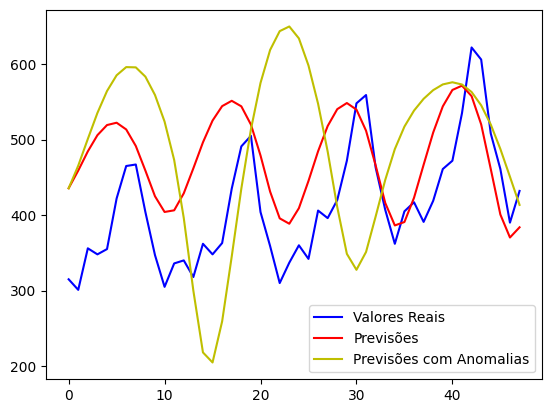

In [54]:
plt.plot(test_values, color='b', label='Valores Reais')
plt.plot(predicted_values, color='r', label='Previsões')
plt.plot(predicted_values_anomalies, color='y', label='Previsões com Anomalias')
plt.legend()
plt.show()